In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [4]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

C:\Users\ksri0\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9207 - loss: 0.2691 - val_accuracy: 0.9594 - val_loss: 0.1409
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9660 - loss: 0.1139 - val_accuracy: 0.9671 - val_loss: 0.1082
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9759 - loss: 0.0767 - val_accuracy: 0.9626 - val_loss: 0.1275
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9822 - loss: 0.0567 - val_accuracy: 0.9731 - val_loss: 0.0957
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9734 - val_loss: 0.0957
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9882 - loss: 0.0366 - val_accuracy: 0.9744 - val_loss: 0.0950
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9903 - loss: 0.0303 - val_accuracy: 0.9711 - val_loss: 0.1091
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9920 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


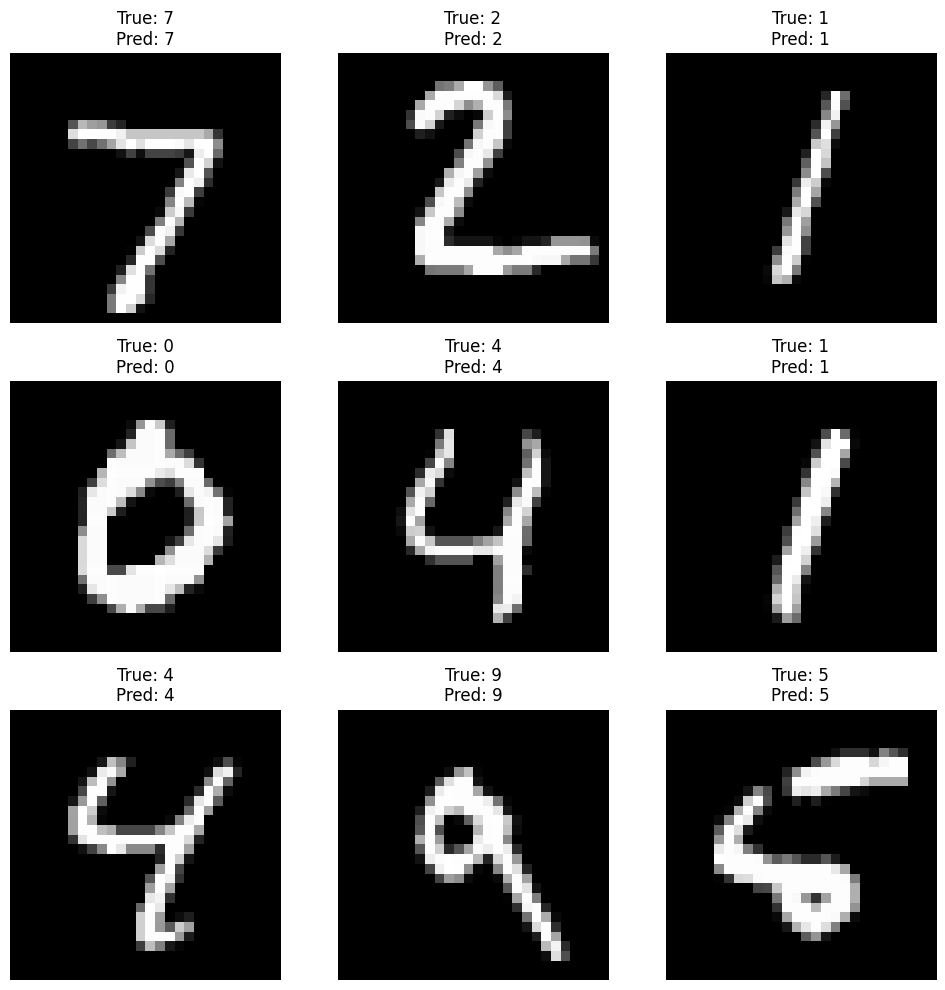

In [7]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
predicted_labels = np.argmax(y_pred, axis=1)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"True: {y_test[i]}\nPred: {predicted_labels[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Number of Wrong Predictions: 278


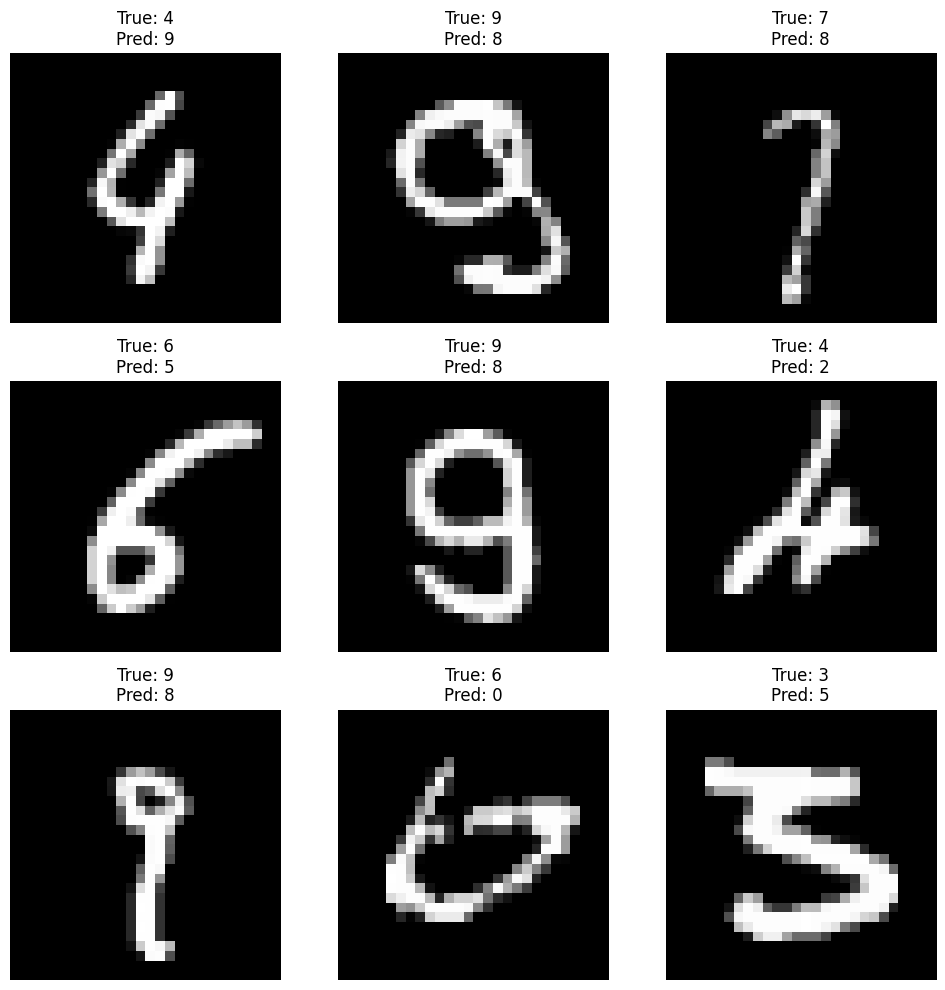

In [9]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
predicted_labels = np.argmax(y_pred, axis=1)

wrong = np.where(predicted_labels != y_test)[0]

print("Number of Wrong Predictions:", len(wrong))

plt.figure(figsize=(10,10))

for i in range(9):
    index = wrong[i]

    plt.subplot(3,3,i+1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(f"True: {y_test[index]}\nPred: {predicted_labels[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()